# Superconductivity Tc Extraction Pipeline + Snippet Verification

Same pipeline as `superconductivity_tc_extraction.ipynb`, but with an enhanced
VLM Tc extraction step (Step 7) that sends **both the full R(T) plot AND a
cropped bottom-left quadrant** in a single Claude call.

**Why?** The VLM struggles with scale on wide-range plots (0-300K) where the
superconducting transition is a tiny feature. By also providing a ~4x zoomed
crop of the bottom-left (where R→0 transitions live), the VLM can verify its
scale reading and refine T_onset/T_zero with better pixel resolution.

## Changes from base notebook
- **Step 7 only**: VLM now receives 2 images (full + bottom-left crop) in one call
- All other steps (0-6, 8-9) are identical


## Setup

In [1]:
# ==============================================================================
# USER CONFIGURATION
# ==============================================================================

# Path to your superconductivity paper (PDF or markdown)
#INPUT_PATH = "/Users/valeriegentzke/Desktop/try_paper.pdf"  # <-- CHANGE THIS
INPUT_PATH = "/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers/0102313_0102313v3.pdf"  # or .md file with embedded images

# Output directory for results (inside the PDF papers folder)
PDF_DIR = "/Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/data/pdf_papers/superconductor_pdfs-random-sample/selected_papers"
OUTPUT_DIR = f"{PDF_DIR}/results"

# Master CSV for multi-paper aggregation (appended after each run)
MASTER_CSV = f"{OUTPUT_DIR}/tc_master.csv"

# Models
GEMINI_MODEL = "gemini-3.0-flash"      # For synthesis / Tc text extraction
CLAUDE_MODEL = "claude-opus-4-6"    #"claude-sonnet-4-20250514"  # For VLM plot data + Tc extraction
LINKER_MODEL = "gemini-3.0-flash"      # For series-to-material matching

# Set to True to skip figure extraction (synthesis + Tc text only)
SKIP_FIGURES = False

In [2]:
# Load environment and imports
import os
import sys
import ssl
import json
import re
import warnings
from pathlib import Path

# ── Fast dependency check (fail early, not at Step 4) ──
def _check_dependencies():
    """Verify critical dependencies are installed and compatible before running the pipeline."""
    errors = []
    
    # Check transformers + CLIP (needed for Florence-2 figure extraction)
    try:
        from transformers import CLIPImageProcessor  # noqa: F401
    except (ImportError, ModuleNotFoundError):
        try:
            import transformers
            ver = transformers.__version__
        except Exception:
            ver = "unknown"
        errors.append(
            f"transformers.CLIPImageProcessor not found (transformers=={ver}).\n"
            f"   Fix: pip install --upgrade transformers\n"
            f"   Or:  uv pip install --upgrade transformers"
        )
    
    # Check anthropic SDK (needed for Claude VLM calls)
    try:
        import anthropic  # noqa: F401
    except ImportError:
        errors.append("anthropic SDK not installed. Fix: pip install anthropic")
    
    # Check dspy (needed for text extraction)
    try:
        import dspy  # noqa: F401
    except ImportError:
        errors.append("dspy not installed. Fix: pip install dspy")
    
    if errors:
        print("=" * 60)
        print("DEPENDENCY CHECK FAILED")
        print("=" * 60)
        for e in errors:
            print(f"  ✗ {e}")
        print("=" * 60)
        raise ImportError("Fix the above dependencies before running the pipeline.")
    else:
        print("[OK] Dependency check passed (transformers/CLIP, anthropic, dspy)")

_check_dependencies()

# Fix SSL certificate issue for uv-managed Python on macOS
# The httpx client (used by anthropic SDK) may fail to find SSL certs
_ssl_cert = ssl.get_default_verify_paths().cafile
if _ssl_cert and os.path.exists(_ssl_cert):
    os.environ.setdefault("SSL_CERT_FILE", _ssl_cert)
    os.environ.setdefault("SSL_CERT_DIR", os.path.dirname(_ssl_cert))

src_path = Path("../../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dotenv import load_dotenv
env_path = Path("../../.env")
load_dotenv(env_path, override=True)

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

import logging
logging.getLogger("pydantic").setLevel(logging.ERROR)
logging.getLogger("LiteLLM").setLevel(logging.ERROR)
logging.getLogger("litellm").setLevel(logging.ERROR)

print("[OK] Environment loaded")
print(f"[OK] src path: {src_path}")
print(f"[OK] SSL_CERT_FILE: {os.environ.get('SSL_CERT_FILE', 'not set')}")

[OK] Dependency check passed (transformers/CLIP, anthropic, dspy)
[OK] Environment loaded
[OK] src path: /Users/valeriegentzke/Documents/Studieren/lemat_synth/lematerial-llm-synthesis/examples/src
[OK] SSL_CERT_FILE: /private/etc/ssl/cert.pem


### ⚡ Fast Mode: Skip to Step 7 (VLM Tc Extraction)

Run **only this cell** instead of Steps 0-3 to jump straight to figure extraction + VLM Tc comparison.
This skips material extraction, synthesis extraction, and Tc text extraction.

**Run order for fast mode:** Cell 2 (config) → Cell 3 (imports) → **this cell** → Cell 15 → Cell 17 → Cell 19 → Cell 21 → Cell 22 → Cell 24 → Cell 35

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# FAST MODE — skip Steps 1-3, set up minimal state for Step 4+
# Only does: load paper text (Step 0) + empty placeholders for Steps 1-3
# ══════════════════════════════════════════════════════════════════════════
from llm_synthesis.models.paper import Paper

input_path = Path(INPUT_PATH)

# ── Extract text from PDF (same as Step 0) ──
if input_path.suffix.lower() == ".pdf":
    from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
    pdf_extractor = MistralPDFExtractor(structured=False)
    with open(input_path, "rb") as f:
        paper_text = pdf_extractor.forward(f.read())
    print(f"[OK] Extracted text from PDF: {len(paper_text):,} chars")
elif input_path.suffix.lower() in (".md", ".txt"):
    paper_text = input_path.read_text(errors="replace")
    print(f"[OK] Loaded text: {len(paper_text):,} chars")
else:
    raise ValueError(f"Unsupported file type: {input_path.suffix}")

# ── Look for SI file ──
SI_PATTERNS = ["_SI", "-SI", "_si", "-si", "_Supporting", "_supporting",
               "_Supplementary", "_supplementary", "_supp", "_Supp"]
si_text = ""
for pattern in SI_PATTERNS:
    for ext in [".pdf", ".md", ".txt"]:
        si_path = input_path.parent / f"{input_path.stem}{pattern}{ext}"
        if si_path.exists():
            print(f"   Found SI: {si_path.name}")
            break
    else:
        continue
    break

# ── Create Paper object ──
paper = Paper(
    name=input_path.stem,
    id=input_path.stem,
    publication_text=paper_text,
    si_text=si_text,
)
print(f"[OK] Paper: {paper.id}")

# ── Empty placeholders so downstream cells don't crash ──
materials = []
all_syntheses = []
text_tc_per_material = {}
print("[FAST MODE] Skipped: materials, synthesis, Tc text extraction")


[OK] Extracted text from PDF: 106,637 chars
[OK] Paper: 0102313_0102313v3
[FAST MODE] Skipped: materials, synthesis, Tc text extraction


---
## Step 0: Load Paper Text

In [4]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.models.paper import Paper

# # SI file detection helpers (same as synthesis_with_performance.ipynb)
# SI_PATTERNS = ["_SI", "-SI", "_si", "-si", "_Supporting", "_supporting",
#                "_Supplementary", "_supplementary", "_supp", "_Supp"]


# def find_si_file(main_paper_path: Path) -> Path | None:
#     parent_dir = main_paper_path.parent
#     main_stem = main_paper_path.stem
#     for pattern in SI_PATTERNS:
#         for ext in [".pdf", ".md", ".txt"]:
#             si_path = parent_dir / f"{main_stem}{pattern}{ext}"
#             if si_path.exists():
#                 return si_path
#     return None


# def load_file_text(path: Path, pdf_extractor=None) -> str:
#     suffix = path.suffix.lower()
#     if suffix == ".pdf":
#         if pdf_extractor is None:
#             from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
#             pdf_extractor = MistralPDFExtractor(structured=False)
#         with open(path, "rb") as f:
#             return pdf_extractor.forward(f.read())
#     elif suffix in [".md", ".txt"]:
#         with open(path, "r", errors="replace") as f:
#             return f.read()
#     else:
#         raise ValueError(f"Unsupported file type: {suffix}")


# # Load main paper
# input_path = Path(INPUT_PATH)
# pdf_extractor = None

# if input_path.suffix.lower() == ".pdf":
#     print(f"Extracting text from PDF: {input_path.name}")
#     from llm_synthesis.transformers.pdf_extraction import MistralPDFExtractor
#     pdf_extractor = MistralPDFExtractor(structured=False)
#     paper_text = load_file_text(input_path, pdf_extractor)
#     print(f"   Main paper: {len(paper_text):,} characters")
# elif input_path.suffix.lower() in [".md", ".txt"]:
#     print(f"Loading markdown: {input_path.name}")
#     paper_text = load_file_text(input_path)
#     print(f"   Main paper: {len(paper_text):,} characters")
# else:
#     raise ValueError(f"Unsupported input type: {input_path}")

# # Load SI file if exists
# si_text = ""
# si_path = find_si_file(input_path)
# if si_path:
#     print(f"   Found SI file: {si_path.name}")
#     try:
#         si_text = load_file_text(si_path, pdf_extractor)
#         print(f"   SI text: {len(si_text):,} characters")
#     except Exception as e:
#         print(f"   [WARN] Failed to load SI file: {e}")

# # Create Paper object
# paper = Paper(
#     name=input_path.stem,
#     id=input_path.stem,
#     publication_text=paper_text,
#     si_text=si_text,
# )

# print(f"\n[OK] Paper loaded: {paper.name}")
# print(f"   Main text: {len(paper.publication_text):,} chars")
# print(f"   SI text: {len(paper.si_text):,} chars")

---
## Step 1: Extract Materials

In [5]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.transformers.material_extraction.dspy_extraction import (
#     DspyTextExtractor,
#     make_dspy_text_extractor_signature,
# )
# from llm_synthesis.utils.dspy_utils import get_llm_from_name
# from llm_synthesis.utils.markdown_utils import clean_text

# material_sig = make_dspy_text_extractor_signature(
#     instructions=(
#         "Extract ALL distinct superconducting material compositions that were synthesized "
#         "and tested in this paper. IMPORTANT: If the paper studies multiple variants "
#         "(e.g., different doping levels x=0.1, x=0.2, x=0.3), list EACH variant "
#         "as a separate material. Focus on materials that were actually synthesized, "
#         "not just mentioned or referenced from other works."
#     ),
#     output_name="materials",
#     output_description=(
#         "ALL distinct synthesized material compositions as a comma-separated list "
#         "using chemical formulas. Include doping levels, substitution amounts, and "
#         "stoichiometry when specified (e.g., 'Ba0.6K0.4Fe2As2, Ba0.85La0.15Fe2As2'). "
#         "Never merge variants into a single generic name."
#     ),
# )

# material_lm = get_llm_from_name(
#     "gemini-3.0-pro",
#     model_kwargs={"temperature": 0.0, "max_tokens": 8000},
# )
# material_extractor = DspyTextExtractor(signature=material_sig, lm=material_lm)

# print("Extracting materials...")
# materials_text = material_extractor.forward(input=clean_text(paper.publication_text))

# materials = [
#     m.strip()
#     for m in materials_text.replace("\n", ",").split(",")
#     if m.strip()
# ]

# print(f"\n{'=' * 60}")
# print(f"MATERIALS FOUND ({len(materials)} total)")
# print("=" * 60)
# for i, mat in enumerate(materials, 1):
#     print(f"  {i}. {mat}")

---
## Step 2: Extract Synthesis Procedures

In [6]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.transformers.synthesis_extraction.dspy_synthesis_extraction import (
#     DspySynthesisExtractor,
#     make_dspy_synthesis_extractor_signature,
# )
# from llm_synthesis.metrics.judge.general_synthesis_judge import (
#     DspyGeneralSynthesisJudge,
#     make_general_synthesis_judge_signature,
# )

# SYNTHESIS_SYSTEM_PROMPT = """You are a helpful assistant that extracts structured synthesis procedures from scientific papers.

# IMPORTANT: For the synthesis_method field, you MUST choose from these exact values:
# 'PVD', 'CVD', 'arc discharge', 'ball milling', 'spray pyrolysis', 'electrospinning',
# 'sol-gel', 'hydrothermal', 'solvothermal', 'precipitation', 'coprecipitation', 'combustion',
# 'microwave-assisted', 'sonochemical', 'template-directed', 'solid-state', 'flux growth',
# 'float zone & Bridgman', 'arc melting & induction melting', 'spark plasma sintering',
# 'electrochemical deposition', 'chemical bath deposition', 'liquid-phase epitaxy', 'self-assembly',
# 'atomic layer deposition', 'molecular beam epitaxy', 'pulsed laser deposition', 'ion implantation',
# 'lithographic patterning', 'wet impregnation', 'incipient wetness impregnation', 'mechanical mixing',
# 'solution-based', 'mechanochemical', 'other'

# For the target_compound_type field, you MUST choose from these exact values:
# 'metals & alloys', 'ceramics & glasses', 'polymers & soft matter', 'composites',
# 'semiconductors & electronic', 'nanomaterials', 'two-dimensional materials',
# 'framework & porous materials', 'biomaterials & biological', 'liquid materials',
# 'hybrid & organic-inorganic', 'functional materials & catalysts', 'energy & sustainability',
# 'smart & responsive materials', 'emerging & quantum materials', 'other'

# If the exact method is not in the list, use the closest match or 'other'."""

# synthesis_sig = make_dspy_synthesis_extractor_signature(
#     instructions=(
#         "Extract the complete structured synthesis procedure for the specified material. "
#         "Include all steps, conditions (temperature, time, atmosphere), equipment, and precursors. "
#         "Be thorough and preserve all quantitative details."
#     ),
# )

# synthesis_lm = get_llm_from_name(
#     GEMINI_MODEL,
#     model_kwargs={"temperature": 0.0, "max_tokens": 32000, "max_retries": 3},
#     system_prompt=SYNTHESIS_SYSTEM_PROMPT,
# )
# synthesis_extractor = DspySynthesisExtractor(signature=synthesis_sig, lm=synthesis_lm)

# # Judge
# judge_lm = get_llm_from_name(
#     GEMINI_MODEL,
#     model_kwargs={"temperature": 0.1, "max_tokens": 8000},
# )
# judge_sig = make_general_synthesis_judge_signature()
# judge = DspyGeneralSynthesisJudge(signature=judge_sig, lm=judge_lm)

# print("[OK] Synthesis extractor and judge initialized")

In [7]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.models.paper import SynthesisEntry

# all_syntheses = []
# text_for_llm = clean_text(paper.publication_text)

# for i, material in enumerate(materials, 1):
#     print(f"\n{'=' * 60}")
#     print(f"EXTRACTING SYNTHESIS {i}/{len(materials)}: {material}")
#     print("=" * 60)

#     try:
#         synthesis = synthesis_extractor.forward(input=(text_for_llm, material))

#         try:
#             evaluation = judge.forward(
#                 (text_for_llm, json.dumps(synthesis.model_dump()), material)
#             )
#             print(f"   [OK] Score: {evaluation.scores.overall_score}/5.0")
#         except Exception as e:
#             print(f"   [WARN] Judge failed: {e}")
#             evaluation = None

#         all_syntheses.append(SynthesisEntry(
#             material=material, synthesis=synthesis, evaluation=evaluation,
#         ))
#         print(f"   Method: {synthesis.synthesis_method}")
#         print(f"   Steps: {len(synthesis.steps)}")

#     except Exception as e:
#         print(f"   [ERROR] {e}")
#         all_syntheses.append(SynthesisEntry(
#             material=material, synthesis=None, evaluation=None,
#         ))

# print(f"\n[OK] Extracted synthesis for {len(all_syntheses)} materials")

---
## Step 3: Extract Tc from Text ★ NEW

Use an LLM to extract critical temperature (Tc) values mentioned in the paper text.
This gives us the **text-reported** Tc for comparison with the VLM-extracted Tc from plots.

In [8]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# # ── Multi-condition Tc text extraction ──
# # This extracts ALL Tc values per material, one per (material, condition) pair.
# tc_text_sig = make_dspy_text_extractor_signature(
#     signature_name="TextToTcMulti",
#     instructions=(
#         "Extract ALL critical temperature (Tc) values reported in this superconductivity paper. "
#         "For EACH material, report ALL Tc values found — one line per (material, condition) "
#         "combination. Conditions include: pressure (e.g., '2.5 GPa'), magnetic field "
#         "(e.g., '9 T'), doping level (e.g., 'x=0.15'), sample type (e.g., 'single-crystal', "
#         "'thin-film', 'polycrystalline'), or any other experimental condition.\n\n"
#         "If no specific condition is mentioned, use 'ambient' as the condition.\n"
#         "Only extract values explicitly stated. Use 'NR' for values not reported."
#     ),
#     input_description="The full publication text from a superconductivity paper.",
#     output_name="tc_values",
#     output_description=(
#         "For each (material, condition) pair, one line in the format:\n"
#         "material_formula | condition: <description or 'ambient'> | superconducting: YES/NO "
#         "| T_onset: <value> K | Tc: <value> K | T_zero: <value> K\n"
#         "Use 'NR' for values not reported. Report ALL conditions for each material."
#     ),
# )

# tc_text_lm = get_llm_from_name(
#     GEMINI_MODEL,
#     model_kwargs={"temperature": 0.0, "max_tokens": 16384},
# )
# tc_text_extractor = DspyTextExtractor(signature=tc_text_sig, lm=tc_text_lm)

# MAX_TEXT_CHARS = 60_000
# if len(text_for_llm) > MAX_TEXT_CHARS:
#     print(f"[INFO] Paper text is {len(text_for_llm):,} chars — truncating to {MAX_TEXT_CHARS:,}")
#     tc_input_text = text_for_llm[:MAX_TEXT_CHARS]
# else:
#     tc_input_text = text_for_llm

# print("Extracting Tc values from text (multi-condition)...")
# try:
#     tc_text_raw = tc_text_extractor.forward(input=tc_input_text)
# except Exception as e:
#     print(f"[WARN] Tc text extraction failed: {e}")
#     tc_text_raw = ""

# print(f"\n{'=' * 60}")
# print("Tc VALUES FROM TEXT (multi-condition)")
# print("=" * 60)
# print(tc_text_raw)


In [9]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# def parse_tc_text_response_multi(raw_text: str) -> list[dict]:
#     """Parse multi-condition Tc text extraction into a list of dicts.
#     Each dict: {material, condition, superconducting, T_onset, Tc_mid, T_zero}
#     """
#     results = []
#     for line in raw_text.strip().split("\n"):
#         line = line.strip()
#         if not line or "|" not in line:
#             continue
#         parts = [p.strip() for p in line.split("|")]
#         if len(parts) < 2:
#             continue
#         material = parts[0].strip()
#         if not material or material.lower().startswith("material"):
#             continue
#
#         entry = {
#             "material": material,
#             "condition": "ambient",
#             "superconducting": False,
#             "T_onset": None,
#             "Tc_mid": None,
#             "T_zero": None,
#         }
#         for part in parts[1:]:
#             part_stripped = part.strip()
#             part_lower = part_stripped.lower()
#             if part_lower.startswith("condition:"):
#                 entry["condition"] = part_stripped.split(":", 1)[1].strip()
#             elif "superconducting" in part_lower:
#                 entry["superconducting"] = "yes" in part_lower
#             else:
#                 match = re.match(
#                     r"(t_onset|tc_mid|tc|t_zero)\s*:\s*(\d+\.?\d*)\s*k?",
#                     part_lower,
#                 )
#                 if match:
#                     key = match.group(1)
#                     val = float(match.group(2))
#                     if key in ("tc", "tc_mid"):
#                         entry["Tc_mid"] = val
#                     elif key == "t_onset":
#                         entry["T_onset"] = val
#                     elif key == "t_zero":
#                         entry["T_zero"] = val
#         results.append(entry)
#     return results


# tc_from_text = parse_tc_text_response_multi(tc_text_raw)

# n_tc = sum(1 for e in tc_from_text if e.get("Tc_mid") is not None)
# n_conds = len(set((e["material"], e["condition"]) for e in tc_from_text))
# print(f"\nParsed {n_tc} Tc values across {n_conds} (material, condition) pairs:")
# for e in tc_from_text:
#     sc = "YES" if e["superconducting"] else "NO"
#     tc = e["Tc_mid"]
#     tc_str = f"{tc:.1f} K" if tc is not None else "NR"
#     cond = e.get("condition", "ambient")
#     print(f"  {e['material']} [{cond}]: SC={sc}, Tc_mid={tc_str}")


---
## Step 4: Extract Figures

In [10]:
if SKIP_FIGURES:
    print("[SKIP] Skipping figure extraction")
    figures = []
else:
    from llm_synthesis.transformers.figure_extraction import FigureExtractorMarkdown

    extractor = FigureExtractorMarkdown(
        segmenter="florence",
        florence_repo_id="amayuelas/plot-visualization-florence-2-lora-32",
    )
    print("Extracting figures using Florence-2...")
    figures = extractor.forward(paper.publication_text)

    print(f"\n{'=' * 60}")
    print(f"FIGURES FOUND ({len(figures)} subfigures)")
    print("=" * 60)
    for i, fig in enumerate(figures):
        print(f"  {i+1}. {fig.figure_reference or f'Figure {i}'}: {fig.figure_class}")

Loading Florence-2 base model: microsoft/Florence-2-base-ft
Loading LoRA adapters from: amayuelas/plot-visualization-florence-2-lora-32
Merging LoRA adapters with base model...
Florence-2 model loaded on mps
Extracting figures using Florence-2...
Found 3 figures in the paper.
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).
Segmented 1 subfigures (Florence).

FIGURES FOUND (3 subfigures)
  1. FIG. 1: Graph plots
  2. FIG. 2: Graph plots
  3. FIG. 3: Graph plots


---
## Step 5: Extract Plot Data (Claude VLM)

Send all figures to Claude to extract (T, R) coordinate data.

In [11]:
if SKIP_FIGURES or not figures:
    print("[SKIP] Skipping plot data extraction")
    plots = []
    plot_figures = []
else:
    from llm_synthesis.transformers.plot_extraction.claude_extraction.plot_data_extraction import (
        ClaudeLinePlotDataExtractor,
    )
    from llm_synthesis.models.figure import FigureInfoWithPaper
    from llm_synthesis.utils.figure_utils import clean_text_from_images

    print(f"Extracting data from {len(figures)} figures using Claude VLM...")

    # Use higher max_tokens so the axis metadata at the end doesn't get truncated
    plot_extractor = ClaudeLinePlotDataExtractor(model_name=CLAUDE_MODEL, max_tokens=4096)

    plots = []
    plot_figures = []

    for i, fig in enumerate(figures):
        print(f"\n  [{i+1}/{len(figures)}] {fig.figure_reference or f'Figure {i}'} ({fig.figure_class})")

        fig_with_paper = FigureInfoWithPaper(
            base64_data=fig.base64_data,
            alt_text=fig.alt_text,
            position=fig.position,
            context_before=fig.context_before,
            context_after=fig.context_after,
            figure_reference=fig.figure_reference,
            figure_class=fig.figure_class,
            quantitative=fig.quantitative,
            paper_text=clean_text_from_images(paper.publication_text),
            si_text=paper.si_text,
        )

        try:
            plot_data = plot_extractor.forward(fig_with_paper)
            if plot_data and plot_data.name_to_coordinates:
                plots.append(plot_data)
                plot_figures.append(fig)
                series_names = list(plot_data.name_to_coordinates.keys())
                print(f"    [OK] {len(series_names)} series: {series_names}")
                print(f"    Axes: x={repr(plot_data.x_axis_label)} [{repr(plot_data.x_axis_unit)}]"
                      f"  y={repr(plot_data.y_left_axis_label)} [{repr(plot_data.y_left_axis_unit)}]")
            else:
                print(f"    [--] No extractable data")
        except Exception as e:
            print(f"    [ERROR] {e}")

    print(f"\n[OK] Extracted data from {len(plots)} plots")
    print(f"   Claude VLM cost: ${plot_extractor.get_cost():.4f}")

Extracting data from 3 figures using Claude VLM...

  [1/3] FIG. 1 (Graph plots)
    [OK] 1 series: ['$\\rho_{xx}$ MgB₂']
    Axes: x='T' ['K']  y='$\\rho_{xx}$' ['$\\mu\\Omega$ cm']

  [2/3] FIG. 2 (Graph plots)
    [OK] 1 series: ['$R_H$ at 5T']
    Axes: x='T' ['K']  y='$R_H$' ['$\\times 10^{-12}$ m³/C']

  [3/3] FIG. 3 (Graph plots)
    [OK] 1 series: ['Series_Name']
    Axes: x='$T^{1.8}$' ['$\\times 10^3$ K']  y='$\\cot \\Theta_H$' ['$\\times 10^3$']

[OK] Extracted data from 3 plots
   Claude VLM cost: $0.0424


---
## Step 6: Filter for R(T) Plots

Use `PlotFilterConfig.for_superconductivity()` to keep only plots that look like
Resistance vs Temperature (R(T)) curves.

In [12]:
import importlib
import llm_synthesis.config.plot_filter_config
importlib.reload(llm_synthesis.config.plot_filter_config)
from llm_synthesis.config.plot_filter_config import PlotFilterConfig

import llm_synthesis.transformers.performance_linking.plot_filter
importlib.reload(llm_synthesis.transformers.performance_linking.plot_filter)
from llm_synthesis.transformers.performance_linking.plot_filter import PlotFilter

filter_config = PlotFilterConfig.for_superconductivity()
plot_filter = PlotFilter(filter_config)

print("Plot Filter (Superconductivity):")
print(f"   X-axis labels: {filter_config.x_axis_labels}")
print(f"   X-axis units: {filter_config.x_axis_units}")
print(f"   Y-axis keywords: {filter_config.y_axis_keywords[:5]}... ({len(filter_config.y_axis_keywords)} total)")
print(f"   Y-axis units: {filter_config.y_axis_units[:5]}... ({len(filter_config.y_axis_units)} total)")
print(f"   Y-axis exclude: {filter_config.y_axis_exclude_patterns[:4]}...")


def fallback_check_rt_plot(plot, fig) -> bool:
    """Fallback: check if a plot with missing axis metadata is an R(T) plot
    by looking at the figure caption/context and the data itself."""
    context = f"{fig.context_before or ''} {fig.context_after or ''} {fig.alt_text or ''}".lower()
    rt_context_hints = [
        "resistivity", "resistance", "ρ(t)", "ρ vs", "r(t)", "r vs t",
        "t (k)", "t [k]", "temperature dependence of ρ",
        "temperature dependence of the resistivity",
        "temperature dependence of the resistance",
        "μω cm", "μω·cm", "mω cm",
    ]
    return any(hint in context for hint in rt_context_hints)


def _is_axis_missing(label, unit) -> bool:
    """Check if axis metadata is effectively missing (None or empty string)."""
    return (not label or not label.strip()) and (not unit or not unit.strip())


if plots:
    # ── Debug: show what Claude VLM extracted for each plot ──
    print(f"\n{'=' * 60}")
    print("DEBUG: Extracted axis labels for all plots")
    print("=" * 60)
    for i, plot in enumerate(plots):
        fig = plot_figures[i]
        print(f"\n  Plot {i}: {plot.title or 'N/A'}")
        print(f"    x_axis_label: {repr(plot.x_axis_label)}")
        print(f"    x_axis_unit:  {repr(plot.x_axis_unit)}")
        print(f"    y_left_axis_label: {repr(plot.y_left_axis_label)}")
        print(f"    y_left_axis_unit:  {repr(plot.y_left_axis_unit)}")

        x_ok = filter_config.is_relevant_x_axis(plot.x_axis_label, plot.x_axis_unit)
        y_ok = filter_config.is_relevant_y_axis(plot.y_left_axis_label, plot.y_left_axis_unit)
        print(f"    -> x_axis relevant: {x_ok}")
        print(f"    -> y_axis relevant: {y_ok}")

        if not x_ok or not y_ok:
            fb = fallback_check_rt_plot(plot, fig)
            print(f"    -> fallback (context check): {fb}")

    # First pass: standard filter
    relevant_plots, skip_counts = plot_filter.filter_plots(plots, log_skipped=False)

    # Second pass: for rejected plots, try fallback if axis metadata is missing/empty
    rejected_indices = {i for i in range(len(plots))} - {idx for idx, _ in relevant_plots}
    for i in sorted(rejected_indices):
        plot = plots[i]
        fig = plot_figures[i]
        # Use fallback if EITHER axis metadata is missing/empty (not if present but wrong type)
        x_missing = _is_axis_missing(plot.x_axis_label, plot.x_axis_unit)
        y_missing = _is_axis_missing(plot.y_left_axis_label, plot.y_left_axis_unit)
        if (x_missing or y_missing) and fallback_check_rt_plot(plot, fig):
            relevant_plots.append((i, plot))
            missing_info = []
            if x_missing: missing_info.append("x-axis")
            if y_missing: missing_info.append("y-axis")
            print(f"\n  [FALLBACK] Plot {i} included via context check (missing {', '.join(missing_info)} metadata)")

    # Sort by index
    relevant_plots.sort(key=lambda x: x[0])

    print(f"\n{'=' * 60}")
    print("PLOT FILTERING RESULTS")
    print("=" * 60)
    print(f"  Total plots: {len(plots)}")
    print(f"  R(T) plots: {len(relevant_plots)}")
    print(f"  Skipped (wrong x-axis): {skip_counts.get('not_relevant_x', 0)}")
    print(f"  Skipped (wrong y-axis): {skip_counts.get('not_relevant_y', 0)}")

    for idx, plot in relevant_plots:
        print(f"\n  Plot {idx}: {plot.title or 'N/A'}")
        print(f"    X: {plot.x_axis_label} [{plot.x_axis_unit}]")
        print(f"    Y: {plot.y_left_axis_label} [{plot.y_left_axis_unit}]")
        print(f"    Series: {list(plot.name_to_coordinates.keys())}")
else:
    print("\n[SKIP] No plots to filter")
    relevant_plots = []


Plot Filter (Superconductivity):
   X-axis labels: ['temperature', 'temp', 't (k)', 't(k)', 't [k]', 't[k]']
   X-axis units: ['k', '°k', 'kelvin']
   Y-axis keywords: ['resistance', 'resistivity', 'r(t)', 'r/r', 'ρ']... (16 total)
   Y-axis units: ['ω', 'ohm', 'mω', 'μω', 'ω·cm']... (17 total)
   Y-axis exclude: ['ρ-ρ', 'r-r', 'ρ−ρ', 'r−r']...

DEBUG: Extracted axis labels for all plots

  Plot 0: $\rho_{xx}$ - T for MgB₂
    x_axis_label: 'T'
    x_axis_unit:  'K'
    y_left_axis_label: '$\\rho_{xx}$'
    y_left_axis_unit:  '$\\mu\\Omega$ cm'
    -> x_axis relevant: True
    -> y_axis relevant: True

  Plot 1: Hall coefficient measured at 5T
    x_axis_label: 'T'
    x_axis_unit:  'K'
    y_left_axis_label: '$R_H$'
    y_left_axis_unit:  '$\\times 10^{-12}$ m³/C'
    -> x_axis relevant: True
    -> y_axis relevant: False
    -> fallback (context check): False

  Plot 2: Cotangent of Hall angle at 5T
    x_axis_label: '$T^{1.8}$'
    x_axis_unit:  '$\\times 10^3$ K'
    y_left_axis_la

---
## Step 7: Extract Tc from R(T) Plots via VLM (Pipeline A) ★ NEW

For each relevant R(T) plot, ask Claude to directly determine Tc using
the geometric construction (T_onset, T_zero, Tc_mid) — this is the approach
that was validated with ~11% average error.

In [13]:
import base64
import io

from PIL import Image as PILImage

from llm_synthesis.services.llm_api.claude import ClaudeAPIClient


def crop_bottom_left_quadrant(img_base64: str) -> str:
    """Crop bottom-left quadrant → base64 PNG.  ~4x resolution in the SC transition region."""
    img_bytes = base64.b64decode(img_base64)
    img = PILImage.open(io.BytesIO(img_bytes))
    w, h = img.size
    cropped = img.crop((0, h // 2, w // 2, h))
    buf = io.BytesIO()
    cropped.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")


# ── PROMPT A: Original (single image) ──
PROMPT_TEMPLATE_ORIGINAL = """
You are analyzing a Resistance (or Resistivity) vs Temperature plot from a
superconductivity paper. Your task is to determine the critical temperature
Tc for each series using the standard geometric construction.

CRITICAL DISTINCTION — SUPERCONDUCTING TRANSITION vs NORMAL METALLIC BEHAVIOR:
Many materials (especially heavy-fermion compounds like CeCoIn5, CeRhIn5, etc.)
show a GRADUAL decrease in resistivity over a WIDE temperature range (e.g., from
50 K down to 5 K). This is NORMAL metallic behavior (Kondo coherence, phonon
scattering reduction, etc.) and is NOT a superconducting transition.

The superconducting transition has these characteristics:
  - It is a SHARP, near-vertical drop in resistance
  - It occurs over a NARROW temperature range (typically 0.1 to 3 K wide)
  - Resistance drops from a finite value all the way to ZERO (or very close to zero)
  - It looks like a cliff or step function, not a gradual slope

If you see a curve that gradually decreases over 10-50 K, that is NOT
superconductivity — it is normal metallic/Kondo behavior.

STEP 0 — EXAMINE THE FULL FIGURE (main plot + any insets/panels):
a) Identify ALL panels in the figure: the main plot and any insets, secondary
   panels, or embedded sub-plots. For each one, describe:
     - What quantity is on each axis (e.g., rho vs T, Tc vs x, phase diagram, etc.)
     - The axis ranges and tick marks
     - Whether it contains information relevant to determining Tc

b) CATEGORIZE each inset/panel into one of these types:
     (i)   ZOOMED R(T): A magnified view of the transition region.
           -> Use this PREFERENTIALLY for geometric Tc construction.
     (ii)  Tc SUMMARY: Shows Tc vs composition/pressure/doping/field.
           -> Read Tc values DIRECTLY from this panel.
     (iii) OTHER: Not useful for Tc determination.

c) Read ALL numbered tick marks on the main plot axes.

d) CRITICAL — SCALE AWARENESS: If the temperature axis spans a wide range
   (e.g., 0-300 K) and the transitions happen in a small fraction, prefer
   reading from a zoomed inset if available.

{figure_caption_block}

STEP 0.5 — EXTRACT Tc FROM SUMMARY INSETS (if any type-(ii) inset found):
Read Tc values directly from it:
  inset_tc_<series_name>: <value> K
These serve as a REFERENCE for Step 4 cross-check.

STEP 1 — IDENTIFY SERIES:
{series_name_instruction}
List every distinct curve visible in the plot.

STEP 2 — READ RESISTANCE VALUES AT LOWEST AND HIGHEST TEMPERATURE:
For EACH series read:
  a) R_at_lowest_T: resistance at the LOWEST temperature shown
  b) R_at_highest_T: resistance at the HIGHEST temperature shown

STEP 3 — CONFIRM SUPERCONDUCTIVITY:
Superconducting ONLY if R_at_lowest_T is approximately zero.

STEP 4 — GEOMETRIC Tc CONSTRUCTION (only for confirmed superconductors):
Use a zoomed inset if available, otherwise the main plot.

IMPORTANT — SCAN FROM HIGH T TO LOW T (right to left on the plot):

  a) R_normal: Starting from the HIGH-temperature side, read the resistance
     on the plateau IMMEDIATELY BEFORE the sharp superconducting drop.
     NOT the maximum resistance at 300 K — the value just above the drop.

  b) T_onset: Scanning LEFT from R_normal, the temperature where resistance
     FIRST begins to drop sharply. This is the HIGH-temperature edge.

  c) T_zero: Continue scanning LEFT. The temperature where resistance FIRST
     reaches approximately zero. NOT the lowest temperature in the dataset.

     EXAMPLE: If R~0 from 2 K to 25 K, then T_zero ≈ 25 K (NOT 2 K).
     T_zero is where the flat R~0 region ENDS going to higher T.

  d) SANITY CHECK: T_onset - T_zero should be 0.5-5 K. If >10 K, re-examine.

  e) Tc_mid = (T_onset + T_zero) / 2.  Should be in the MIDDLE of the sharp
     drop, not at the left edge of the data.

  f) Delta_Tc = T_onset - T_zero

  g) CROSS-CHECK: If inset Tc differs by >20%, use inset value.

COMMON MISTAKE: Do NOT confuse the lowest data-point temperature (e.g., 2 K)
with T_zero. If R=0 from 2 K up to 25 K, T_zero ≈ 25 K.

STEP 5 — RELATIVE ORDERING OF TRANSITIONS:
Compare which series transitions at higher vs lower T.

Output format:

inset_detected: <yes/no>
inset_type: <"zoomed_rt" | "tc_summary" | "other" | "none">
inset_description: <brief description or "N/A">
inset_axes: <tick marks if present, otherwise "N/A">
inset_tc_values: <series: value K, ... or "N/A">
main_x_axis_ticks: <list>
main_y_axis_ticks: <list>

Series: <name>
R_at_lowest_T: <value and unit>
R_at_highest_T: <value and unit>
superconducting: <YES/NO>
[If NO:]
reason: <why not superconducting>
[If YES:]
R_normal: <value and unit>
T_onset: <value> K
T_zero: <value> K
Tc_mid: <value> K
Delta_Tc: <value> K
source: <"inset" or "main plot" or "zoomed inset">

relative_ordering: <which series transitions first, etc.>

Do not output any other text.
"""


# ── PROMPT B: Snippet-enhanced (two images) ──
PROMPT_TEMPLATE_SNIPPET = """
You are analyzing a Resistance (or Resistivity) vs Temperature plot from a
superconductivity paper. You have TWO views of the same figure:
  - Image 1: The FULL plot (complete axes, legend, all series)
  - Image 2: A ZOOMED crop of the BOTTOM-LEFT quadrant (low temperature,
    low resistance region) — this has ~4x the pixel resolution in the
    transition region where superconducting drops happen.

Your task is to determine the critical temperature Tc for each series using
the standard geometric construction.

CRITICAL DISTINCTION — SUPERCONDUCTING TRANSITION vs NORMAL METALLIC BEHAVIOR:
Many materials (especially heavy-fermion compounds like CeCoIn5, CeRhIn5, etc.)
show a GRADUAL decrease in resistivity over a WIDE temperature range (e.g., from
50 K down to 5 K). This is NORMAL metallic behavior (Kondo coherence, phonon
scattering reduction, etc.) and is NOT a superconducting transition.

The superconducting transition has these characteristics:
  - It is a SHARP, near-vertical drop in resistance
  - It occurs over a NARROW temperature range (typically 0.1 to 3 K wide)
  - Resistance drops from a finite value all the way to ZERO (or very close to zero)
  - It looks like a cliff or step function, not a gradual slope

STEP 0 — EXAMINE BOTH IMAGES:
a) From Image 1 (full plot): Identify ALL panels, insets, legend entries,
   axis labels, axis units, and axis ranges. Read ALL numbered tick marks.

b) From Image 2 (bottom-left crop): Read the tick marks visible in this
   zoomed view. These are CRITICAL for precise Tc determination. Note:
   - What temperature range is visible?
   - What resistance range is visible?
   - Can you see individual data points or transitions more clearly?

   CROP VALIDATION: Verify that Image 2 actually shows the bottom-left
   region of Image 1. The crop's x-axis should start at the same minimum
   temperature as Image 1, and its y-axis should start at the same minimum
   resistance. If the crop does NOT match (e.g., wrong axis labels, wrong
   scale, or it shows a different panel/inset), IGNORE Image 2 entirely
   and use only Image 1 for all analysis.

c) CATEGORIZE each inset/panel into:
     (i)   ZOOMED R(T) -> Use PREFERENTIALLY for geometric Tc construction.
     (ii)  Tc SUMMARY  -> Read Tc values DIRECTLY.
     (iii) OTHER        -> Note but do not use.

d) CRITICAL — SCALE AWARENESS: Compare tick marks from Image 1 vs Image 2.
   If the full plot spans 0-300 K but the crop shows 0-150 K with clear tick
   marks, USE THE CROP for reading transition temperatures. If the transition
   falls outside the crop, use the full image.

{figure_caption_block}

STEP 0.5 — EXTRACT Tc FROM SUMMARY INSETS (if any type-(ii) inset found):
Read Tc values directly:
  inset_tc_<series_name>: <value> K
These serve as a REFERENCE for Step 4 cross-check.

STEP 1 — IDENTIFY SERIES:
{series_name_instruction}
List every distinct curve visible in the plot.

STEP 2 — READ RESISTANCE VALUES AT LOWEST AND HIGHEST TEMPERATURE:
For EACH series, use Image 2 (crop) for low-T values if the series is visible there:
  a) R_at_lowest_T: resistance at the LOWEST temperature
  b) R_at_highest_T: resistance at the HIGHEST temperature

STEP 3 — CONFIRM SUPERCONDUCTIVITY:
Superconducting ONLY if R_at_lowest_T is approximately zero.

STRICT ZERO CHECK (use Image 2 crop for better precision):
In the cropped view, check whether the series data points at low T are
truly sitting ON the y=0 line. With the higher resolution of the crop,
you can distinguish between R≈0 (touching the x-axis) and R that is merely
small but nonzero (floating above the x-axis). If a series has R clearly
above zero in the crop — even if it looked close to zero in the full image
— it is NOT superconducting.

STEP 4 — GEOMETRIC Tc CONSTRUCTION (only for confirmed superconductors):
Use the best view — in order of preference:
  1. A zoomed inset (if present in the figure)
  2. Image 2 (bottom-left crop) — if the transition is visible there
  3. Image 1 (full plot) — only if the transition is outside the crop

IMPORTANT — SCAN FROM HIGH T TO LOW T (right to left on the plot):

  a) R_normal: Starting from the HIGH-temperature side, read the resistance
     value on the plateau IMMEDIATELY BEFORE the sharp superconducting drop.
     This is the normal-state resistance just above the transition — NOT the
     maximum resistance at 300 K.

  b) T_onset: Scanning LEFT from R_normal, find the temperature where the
     resistance FIRST begins to drop sharply below the normal-state plateau.
     This is the HIGH-temperature edge of the transition.

  c) T_zero: Continue scanning LEFT. T_zero is the temperature where the
     resistance FIRST reaches approximately zero. This is the LOW-temperature
     edge of the transition. T_zero is NOT the lowest temperature in the
     dataset — it is the temperature where R first hits zero.

     EXAMPLE: If data points are at R~0 from 2 K to 25 K, and then R rises
     sharply above 25 K, then T_zero ≈ 25 K (NOT 2 K). T_zero is where the
     flat R~0 region ENDS going right (i.e., where the transition begins
     going from low T upward).

  d) SANITY CHECK: T_onset - T_zero should typically be 0.5-5 K for most
     superconductors. If > 10 K, you are probably measuring metallic decline,
     NOT the SC transition. Re-examine.

  e) Tc_mid = (T_onset + T_zero) / 2.   This should be in the MIDDLE of the
     sharp drop, not at the left edge of the data.

  f) Delta_Tc = T_onset - T_zero

  g) CROSS-CHECK: If inset Tc differs by >20%, use inset value.

COMMON MISTAKE TO AVOID: Do NOT confuse the lowest temperature data point
(e.g., 2 K) with T_zero. If R is zero from 2 K all the way up to 25 K,
then T_zero ≈ 25 K. The VLM must identify WHERE the drop happens, not
where the data starts.

STEP 5 — RELATIVE ORDERING OF TRANSITIONS:
Compare which series transitions at higher vs lower T.

Output format:

inset_detected: <yes/no>
inset_type: <"zoomed_rt" | "tc_summary" | "other" | "none">
inset_description: <brief description or "N/A">
inset_axes: <tick marks if present, otherwise "N/A">
inset_tc_values: <series: value K, ... or "N/A">
crop_x_range: <temperature range visible in Image 2, e.g., "0 to 150 K">
crop_y_range: <resistance range visible in Image 2>
main_x_axis_ticks: <list>
main_y_axis_ticks: <list>

Series: <name>
R_at_lowest_T: <value and unit>
R_at_highest_T: <value and unit>
superconducting: <YES/NO>
[If NO:]
reason: <why not superconducting>
[If YES:]
R_normal: <value and unit>
T_onset: <value> K
T_zero: <value> K
Tc_mid: <value> K
Delta_Tc: <value> K
source: <"inset" or "main plot" or "zoomed inset" or "bottom-left crop">

relative_ordering: <which series transitions first, etc.>

Do not output any other text.
"""



def extract_figure_caption(fig_ref: str, paper_text: str, max_chars: int = 500) -> str:
    """Extract the caption for a figure from the paper text."""
    if not fig_ref or not paper_text:
        return ""
    
    # Extract figure number from reference like "Fig. 1", "Figure 2(a)"
    ref_match = re.search(r'(\d+)', fig_ref)
    if not ref_match:
        return ""
    fig_num = ref_match.group(1)
    
    # Pattern: "Fig. N" or "Figure N" followed by caption text,
    # ending at a double newline or next figure/table reference
    pat = (
        r'(?:Fig(?:ure)?\.?\s*' + fig_num + r')\s*[.:)\s]\s*'
        r'(.*?)'
        r'(?:\n\n|\n(?:Fig|FIG|TABLE|\\)|$)'
    )
    match = re.search(pat, paper_text, re.IGNORECASE | re.DOTALL)
    if match:
        caption = re.sub(r'\s+', ' ', match.group(1).strip())
        return caption[:max_chars]
    
    # Fallback: grab up to 300 chars after "Fig. N"
    simple = re.search(
        r'(?:Fig(?:ure)?\.?\s*' + fig_num + r')\s*[.:)]\s*(.{10,300})',
        paper_text, re.IGNORECASE
    )
    if simple:
        return re.sub(r'\s+', ' ', simple.group(1).strip())[:max_chars]
    
    return ""


def build_tc_prompt(known_series_names: list[str] | None = None,
                    use_snippet: bool = False,
                    figure_caption: str = "") -> str:
    """Build the Tc extraction prompt.

    Args:
        known_series_names: Series names from Step 5 to inject.
        use_snippet: If True, use the two-image prompt (PROMPT_TEMPLATE_SNIPPET).
                     If False, use the single-image prompt (PROMPT_TEMPLATE_ORIGINAL).
        figure_caption: Figure caption text from the paper (for context).
    """
    template = PROMPT_TEMPLATE_SNIPPET if use_snippet else PROMPT_TEMPLATE_ORIGINAL
    if known_series_names and len(known_series_names) > 0:
        names_list = "\n".join(f"  {i+1}. {name}" for i, name in enumerate(known_series_names))
        instruction = (
            "The following series were previously identified in this plot. "
            "You MUST use these EXACT names in your output (in the 'Series:' lines):\n"
            f"{names_list}\n\n"
            "If you see additional curves not in this list, add them with descriptive names."
        )
    else:
        instruction = "List every distinct curve (by legend label, color, marker)."
    
    prompt = template.format(
        series_name_instruction=instruction,
        figure_caption_block="{figure_caption_block}",  # placeholder preserved
    )
    
    # Inject caption block
    if figure_caption:
        caption_block = (
            f"FIGURE CAPTION (from the paper):\n"
            f"  {figure_caption}\n\n"
            f"Use this caption to understand which materials/samples are shown, "
            f"doping levels, pressure conditions, etc. This helps you correctly "
            f"identify and label each series."
        )
    else:
        caption_block = ""
    
    return prompt.replace("{figure_caption_block}", caption_block)


def parse_direct_tc_response(response_text: str) -> dict:
    """Parse the VLM Tc response into {series_name: {superconducting, tc_mid, ...}}."""
    results = {}
    current = None
    inset_tc_raw = None

    for line in response_text.strip().split("\n"):
        line = line.strip()
        if line.lower().startswith("inset_tc_values:") and current is None:
            inset_tc_raw = line.split(":", 1)[1].strip()
            continue
        if line.startswith("Series:"):
            current = line.split(":", 1)[1].strip()
            results[current] = {}
        elif current and ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower().replace(" ", "_")
            val = val.strip()
            if key == "superconducting":
                results[current][key] = val.upper().startswith("YES")
            elif key in ("reason", "source"):
                results[current][key] = val
            else:
                match = re.search(r"(\d+\.?\d*|\d*\.\d+)", val)
                if match:
                    try:
                        results[current][key] = float(match.group(1))
                    except ValueError:
                        results[current][key] = val
                elif "no transition" in val.lower() or "n/a" in val.lower():
                    results[current][key] = None
                else:
                    results[current][key] = val

    if inset_tc_raw and inset_tc_raw.lower() not in ("n/a", "none", ""):
        inset_pairs = _parse_inset_tc_values(inset_tc_raw, results)
        for series_name, tc_val in inset_pairs.items():
            if series_name in results:
                results[series_name]["inset_tc"] = tc_val

    return results


def _parse_inset_tc_values(raw: str, known_series: dict) -> dict:
    """Parse inset_tc_values string into {series_name: float}."""
    result = {}
    for entry in raw.split(","):
        entry = entry.strip()
        if not entry or ":" not in entry:
            continue
        name_part, val_part = entry.rsplit(":", 1)
        name_part = name_part.strip()
        val_part = val_part.strip()
        match = re.search(r"(\d+\.?\d*|\d*\.\d+)", val_part)
        if match:
            tc_val = float(match.group(1))
            if name_part in known_series:
                result[name_part] = tc_val
            else:
                np_lower = name_part.lower().replace(" ", "")
                for ks in known_series:
                    ks_lower = ks.lower().replace(" ", "")
                    if np_lower == ks_lower or np_lower in ks_lower or ks_lower in np_lower:
                        result[ks] = tc_val
                        break
    return result


print("[OK] Tc VLM extractor ready — original prompt + snippet prompt + shared parsers")


[OK] Tc VLM extractor ready — original prompt + snippet prompt + shared parsers


In [14]:
# ── Sanity check: flag suspiciously wide "transitions" + inset cross-validation ──
def sanity_check_delta_tc(vlm_results: dict) -> dict:
    corrected = {}
    for series_name, vals in vlm_results.items():
        corrected[series_name] = dict(vals)
        
        vlm_says_sc = vals.get("superconducting", False)
        if not vlm_says_sc:
            inset_tc = vals.get("inset_tc")
            if inset_tc is not None and inset_tc > 0:
                corrected[series_name]["superconducting"] = True
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_inset_override"] = (
                    f"VLM said SC=NO, but inset Tc={inset_tc:.1f} K found. Using inset value."
                )
            continue
        
        delta = vals.get("delta_tc")
        if delta is not None and delta > 10:
            inset_tc = vals.get("inset_tc")
            if inset_tc is not None and inset_tc > 0:
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_sanity_override"] = (
                    f"Delta_Tc={delta:.1f} K too wide. Using inset Tc={inset_tc:.1f} K."
                )
                for k in ("t_onset", "t_zero", "delta_tc"):
                    corrected[series_name].pop(k, None)
            else:
                corrected[series_name]["superconducting"] = False
                corrected[series_name]["_sanity_override"] = (
                    f"Delta_Tc={delta:.1f} K too wide. Likely metallic decline."
                )
                for k in ("tc_mid", "t_onset", "t_zero", "delta_tc"):
                    corrected[series_name].pop(k, None)
            continue
        
        tc_mid = vals.get("tc_mid")
        inset_tc = vals.get("inset_tc")
        if tc_mid is not None and inset_tc is not None and inset_tc > 0:
            relative_diff = abs(tc_mid - inset_tc) / inset_tc
            if relative_diff > 0.20:
                corrected[series_name]["tc_mid"] = inset_tc
                corrected[series_name]["source"] = "inset"
                corrected[series_name]["_inset_override"] = (
                    f"Geometric Tc_mid={tc_mid:.1f} K vs inset Tc={inset_tc:.1f} K "
                    f"({relative_diff*100:.0f}% off). Using inset."
                )
    return corrected


# ═══════════════════════════════════════════════════════════════════════════════
# Run Tc extraction: ORIGINAL (single image) vs SNIPPET (full + crop)
# Uses CLAUDE_MODEL from the config cell at the top.
# ═══════════════════════════════════════════════════════════════════════════════
import anthropic

tc_from_vlm_original = {}   # {plot_idx: {series: {...}}}
tc_from_vlm_snippet  = {}   # {plot_idx: {series: {...}}}

if relevant_plots:
    _anthropic_client = anthropic.Anthropic()
    _cost_original = 0.0
    _cost_snippet  = 0.0

    def _img_type(b64: str) -> str:
        return "image/jpeg" if b64.startswith("/9j/") else "image/png"

    def _call_vlm(fig_b64: str, prompt: str, crop_b64: str | None = None) -> tuple[str, float]:
        """Claude VLM call — single image or two images (full + crop)."""
        content = []
        if crop_b64:
            content.append({"type": "text", "text": "Image 1 — FULL R(T) plot:"})
        content.append({"type": "image", "source": {"type": "base64", "media_type": _img_type(fig_b64), "data": fig_b64}})
        if crop_b64:
            content.append({"type": "text", "text": "Image 2 — ZOOMED bottom-left quadrant (low T, low R region):"})
            content.append({"type": "image", "source": {"type": "base64", "media_type": _img_type(crop_b64), "data": crop_b64}})
        content.append({"type": "text", "text": prompt})

        msg = _anthropic_client.messages.create(
            model=CLAUDE_MODEL, max_tokens=4096, temperature=0.0,
            messages=[{"role": "user", "content": content}],
        )
        cost = (msg.usage.input_tokens / 1e6) * 3.0 + (msg.usage.output_tokens / 1e6) * 15.0
        return msg.content[0].text, cost

    for idx, plot in relevant_plots:
        fig = plot_figures[idx]
        known_series = list(plot.name_to_coordinates.keys())
        ref = fig.figure_reference or f"Plot {idx}"

        # Extract figure caption from paper text
        caption = extract_figure_caption(ref, paper.publication_text)

        print(f"\n{'=' * 70}")
        print(f"Plot {idx}: {ref}")
        print(f"  X: {plot.x_axis_label} [{plot.x_axis_unit}]")
        print(f"  Y: {plot.y_left_axis_label} [{plot.y_left_axis_unit}]")
        print(f"  Known series: {known_series}")
        if caption:
            print(f"  Caption: {caption[:100]}{'...' if len(caption) > 100 else ''}")
        print("=" * 70)

        # ── A) ORIGINAL (single image) ──
        prompt_orig = build_tc_prompt(known_series_names=known_series, use_snippet=False, figure_caption=caption)
        try:
            resp, cost = _call_vlm(fig.base64_data, prompt_orig)
            _cost_original += cost
            parsed = sanity_check_delta_tc(parse_direct_tc_response(resp))
            tc_from_vlm_original[idx] = parsed

            print(f"\n  [ORIGINAL] (${cost:.4f})")
            for sn, v in parsed.items():
                sc = "Y" if v.get("superconducting") else "N"
                tc = f"{v['tc_mid']:.1f} K" if v.get("tc_mid") else "—"
                src = v.get("source", "main plot")
                ovr = v.get("_sanity_override", v.get("_inset_override", ""))
                print(f"    {sn}: SC={sc}  Tc={tc}  (src: {src}){f'  ⚠ {ovr}' if ovr else ''}")
        except Exception as e:
            print(f"  [ORIGINAL ERROR] {e}")

        # ── B) SNIPPET (full + crop) ──
        crop_b64 = crop_bottom_left_quadrant(fig.base64_data)
        prompt_snip = build_tc_prompt(known_series_names=known_series, use_snippet=True, figure_caption=caption)
        try:
            resp, cost = _call_vlm(fig.base64_data, prompt_snip, crop_b64=crop_b64)
            _cost_snippet += cost
            parsed = sanity_check_delta_tc(parse_direct_tc_response(resp))
            tc_from_vlm_snippet[idx] = parsed

            print(f"\n  [SNIPPET]  (${cost:.4f})")
            for sn, v in parsed.items():
                sc = "Y" if v.get("superconducting") else "N"
                tc = f"{v['tc_mid']:.1f} K" if v.get("tc_mid") else "—"
                src = v.get("source", "main plot")
                ovr = v.get("_sanity_override", v.get("_inset_override", ""))
                print(f"    {sn}: SC={sc}  Tc={tc}  (src: {src}){f'  ⚠ {ovr}' if ovr else ''}")
        except Exception as e:
            print(f"  [SNIPPET ERROR] {e}")

    print(f"\n{'=' * 70}")
    print(f"COST:  Original ${_cost_original:.4f}  |  Snippet ${_cost_snippet:.4f}  |  Total ${_cost_original + _cost_snippet:.4f}")
    print("=" * 70)

    # The rest of the pipeline uses tc_from_vlm — default to snippet
    tc_from_vlm = tc_from_vlm_snippet

else:
    tc_from_vlm_original = {}
    tc_from_vlm_snippet  = {}
    tc_from_vlm = {}
    print("[SKIP] No R(T) plots found for Tc extraction")



Plot 0: FIG. 1
  X: T [K]
  Y: $\rho_{xx}$ [$\mu\Omega$ cm]
  Known series: ['$\\rho_{xx}$ MgB₂']
  Caption: To obtain good ohmic contacts ($<$1 $\Omega$), we coated Au film on contact pads after cleaning the ...

  [ORIGINAL] ($0.0117)
    $\rho_{xx}$ MgB₂: SC=Y  Tc=37.5 K  (src: main plot)

  [SNIPPET]  ($0.0153)
    $\rho_{xx}$ MgB₂: SC=Y  Tc=38.5 K  (src: bottom-left crop)

COST:  Original $0.0117  |  Snippet $0.0153  |  Total $0.0270


### Visualise: Full Image vs Bottom-Left Crop

For each R(T) plot that was sent to the VLM, show the original figure
side-by-side with the bottom-left snippet that the snippet approach receives as extra context.

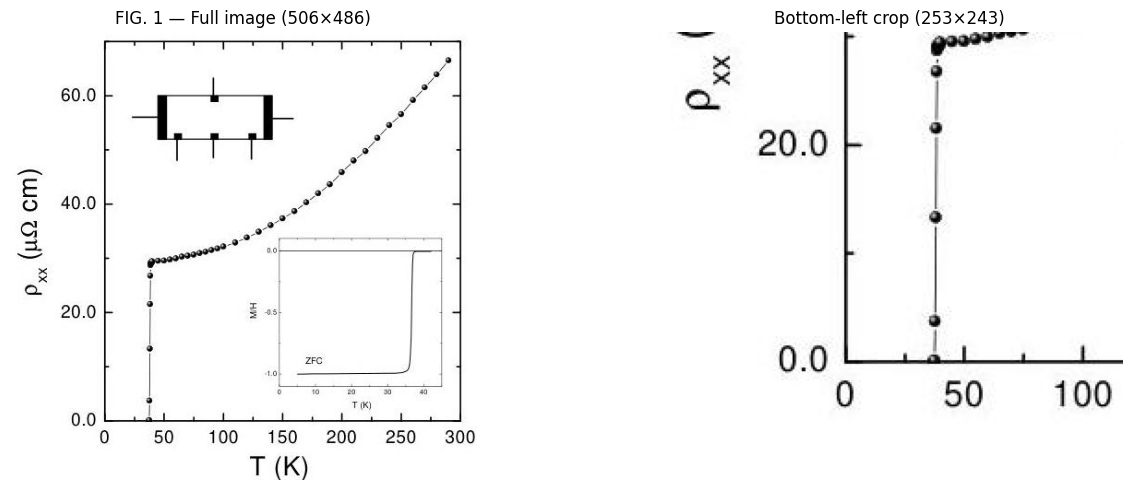

In [15]:
import matplotlib.pyplot as plt
from IPython.display import display

if relevant_plots:
    for idx, plot in relevant_plots:
        fig_obj = plot_figures[idx]
        ref = fig_obj.figure_reference or f"Plot {idx}"

        # Decode full image
        full_bytes = base64.b64decode(fig_obj.base64_data)
        full_img = PILImage.open(io.BytesIO(full_bytes))

        # Crop bottom-left
        w, h = full_img.size
        crop_img = full_img.crop((0, h // 2, w // 2, h))

        # Plot side by side
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].imshow(full_img)
        axes[0].set_title(f"{ref} — Full image ({w}×{h})")
        axes[0].axis("off")

        axes[1].imshow(crop_img)
        axes[1].set_title(f"Bottom-left crop ({w//2}×{h//2})")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("[SKIP] No relevant plots to visualise.")



---
## Step 8: Link Plot Series to Materials

In [16]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# if SKIP_FIGURES or not relevant_plots:
#     print("[SKIP] Skipping performance linking")
#     plot_mappings = []
# else:
#     import dspy
#     from llm_synthesis.transformers.performance_linking.series_material_linker import (
#         SeriesMaterialLinker,
#     )
#     from llm_synthesis.transformers.performance_linking.base import LinkingInput
#     from llm_synthesis.models.performance import PlotMaterialMapping

#     print(f"Linking plot series to {len(materials)} materials...")

#     linker_lm = get_llm_from_name(
#         LINKER_MODEL,
#         model_kwargs={"temperature": 0.0, "max_tokens": 8000},
#     )
#     series_linker = SeriesMaterialLinker(lm=linker_lm)

#     plot_mappings = []

#     for idx, plot in relevant_plots:
#         fig = plot_figures[idx]
#         series_names = list(plot.name_to_coordinates.keys())

#         print(f"\n  Plot {idx}: {len(series_names)} series")
#         print(f"    Series: {series_names}")

#         context = f"{fig.context_before} {fig.context_after}"
#         plot_meta = {
#             "title": plot.title,
#             "x_axis_label": plot.x_axis_label,
#             "x_axis_unit": plot.x_axis_unit,
#             "y_left_axis_label": plot.y_left_axis_label,
#             "y_left_axis_unit": plot.y_left_axis_unit,
#         }

#         linking_input = LinkingInput(
#             materials=materials,
#             series_names=series_names,
#             context=context,
#             plot_metadata=plot_meta,
#         )
#         validated_mappings = series_linker.forward(linking_input)

#         matched_series = {m.series_name for m in validated_mappings}
#         unmatched = [s for s in series_names if s not in matched_series]

#         plot_mappings.append(PlotMaterialMapping(
#             plot_index=idx,
#             figure_reference=fig.figure_reference,
#             mappings=validated_mappings,
#             unmatched_series=unmatched,
#         ))

#         for m in validated_mappings:
#             print(f"    '{m.series_name}' -> '{m.material_name}' ({m.confidence})")
#         if unmatched:
#             print(f"    [WARN] Unmatched: {unmatched}")

#     print(f"\n[OK] Linking complete")

---
## Step 9: Aggregate & Build Final Results

Combine everything: synthesis + Tc from text + Tc from VLM + R(T) data per material.

In [17]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.utils.performance_utils import aggregate_all_materials_performance
# import unicodedata

# # ── Fuzzy matching helpers ──

# def _normalize_formula(s: str) -> str:
#     """Normalize a material formula for fuzzy matching.
#     Strips parenthetical suffixes like '(9hr-reduced)', normalizes unicode
#     (δ→delta, subscripts→digits), lowercases, removes whitespace."""
#     # Strip parenthetical condition suffixes like "(9hr-reduced)", "(as-sintered)"
#     base = re.sub(r'\s*\([^)]*\)\s*$', '', s).strip()
#     # Normalize unicode: δ→delta, subscript digits, etc.
#     base = base.replace('δ', 'delta').replace('Δ', 'delta')
#     base = base.replace('₀', '0').replace('₁', '1').replace('₂', '2').replace('₃', '3')
#     base = base.replace('₄', '4').replace('₅', '5').replace('₆', '6').replace('₇', '7')
#     base = base.replace('₈', '8').replace('₉', '9').replace('₋', '-')
#     return base.lower().replace(' ', '').replace('−', '-')


# def _find_matching_text_tc(material: str, tc_from_text: dict) -> list:
#     """Find ALL tc_from_text entries whose base formula matches `material`.
#     Returns list of (key, entry) tuples, sorted by Tc (highest first)."""
#     mat_norm = _normalize_formula(material)
#     matches = []
#     for tc_key, tc_entry in tc_from_text.items():
#         key_norm = _normalize_formula(tc_key)
#         if key_norm == mat_norm:
#             matches.append((tc_key, tc_entry))
#     # Sort: superconducting entries first, then by Tc descending
#     matches.sort(key=lambda x: (not x[1].get("superconducting", False), -(x[1].get("Tc_mid") or 0)))
#     return matches


# def _find_vlm_tc_for_series(series_name: str, vlm_results: dict) -> dict:
#     """Fuzzy-match a series name from Step 5/8 against VLM Tc keys from Step 7.
#     The VLM in Step 7 should now use the same names (via prompt injection),
#     but this provides fallback matching just in case."""
#     # Exact match first
#     if series_name in vlm_results:
#         return vlm_results[series_name]
#     # Normalize both and try
#     def _norm(s):
#         s = s.replace('₂', '2').replace('₄', '4').replace('₇', '7').replace('₁', '1')
#         s = s.replace('₃', '3').replace('₅', '5').replace('₆', '6').replace('₈', '8')
#         s = s.replace('₉', '9').replace('₀', '0').replace('₋', '-').replace('δ', 'delta')
#         return s.lower().replace(' ', '')
#     sn = _norm(series_name)
#     for vlm_key, vlm_val in vlm_results.items():
#         # Check if one contains the other (e.g., "9hr-reduced Pr₂Ba₄..." contains "9hr-reduced")
#         vk = _norm(vlm_key)
#         if sn in vk or vk in sn:
#             return vlm_val
#         # Check if they share a distinguishing prefix (e.g., "9hr-reduced")
#         sn_parts = re.split(r'[\s_-]+', series_name.lower())
#         vk_parts = re.split(r'[\s_-]+', vlm_key.lower())
#         # If first 1-2 tokens match, it's likely the same series
#         if len(sn_parts) >= 1 and len(vk_parts) >= 1 and sn_parts[0] == vk_parts[0]:
#             return vlm_val
#     # Single-series fallback: if the VLM only returned 1 series, it must be this one
#     if len(vlm_results) == 1:
#         only_val = next(iter(vlm_results.values()))
#         only_key = next(iter(vlm_results.keys()))
#         print(f"    [FALLBACK] Single-series match: '{series_name}' → '{only_key}'")
#         return only_val
#     return {}


# def _vlm_data_has_tc(vlm_data: dict) -> bool:
#     """Check if VLM data actually contains a Tc value (not just SC=NO with no data)."""
#     return bool(vlm_data.get("superconducting") and vlm_data.get("tc_mid") is not None)


# # Aggregate R(T) performance data per material (coordinates)
# if plot_mappings and plots:
#     performance_data = aggregate_all_materials_performance(materials, plot_mappings, plots)
# else:
#     performance_data = {}

# # ── Build VLM Tc lookup: material -> VLM Tc (via linking) ──
# # IMPORTANT: A material may appear in multiple plots (e.g., R(T) AND χ(T)).
# # We must NOT let a non-SC result from a χ plot overwrite a valid Tc from an R(T) plot.
# # Strategy: only overwrite if the new data has a Tc value, or if no data exists yet.
# vlm_tc_per_material = {}
# for mapping in plot_mappings:
#     plot_idx = mapping.plot_index
#     if plot_idx not in tc_from_vlm:
#         continue
#     vlm_results_for_plot = tc_from_vlm[plot_idx]
#     for sm in mapping.mappings:
#         # Use fuzzy matching to find the VLM Tc entry
#         vlm_data = _find_vlm_tc_for_series(sm.series_name, vlm_results_for_plot)
#         if vlm_data:
#             existing = vlm_tc_per_material.get(sm.material_name)
#             if existing is None:
#                 # No data yet — use whatever we have
#                 vlm_tc_per_material[sm.material_name] = vlm_data
#             elif _vlm_data_has_tc(vlm_data):
#                 if not _vlm_data_has_tc(existing):
#                     # New data has Tc, old data doesn't — upgrade
#                     vlm_tc_per_material[sm.material_name] = vlm_data
#                 # else: both have Tc — keep the first one (from the earlier plot)

# # ── Collect UNMATCHED series (materials in plots but not in materials list) ──
# unmatched_vlm_tc = {}  # {series_name: {tc data}}
# for mapping in plot_mappings:
#     plot_idx = mapping.plot_index
#     if plot_idx not in tc_from_vlm:
#         continue
#     for series_name in mapping.unmatched_series:
#         vlm_data = _find_vlm_tc_for_series(series_name, tc_from_vlm[plot_idx])
#         if vlm_data:
#             unmatched_vlm_tc[series_name] = vlm_data

# # ── Fuzzy-match text Tc to materials ──
# text_tc_per_material = {}
# for material in materials:
#     matches = _find_matching_text_tc(material, tc_from_text)
#     if matches:
#         # Use the best match (highest Tc, superconducting preferred)
#         best_key, best_entry = matches[0]
#         text_tc_per_material[material] = best_entry
#         # Also store ALL variants for the summary
#         text_tc_per_material[material]["_all_variants"] = [
#             {"condition": k, **v} for k, v in matches
#         ]

# # ── Summary Table ──
# print("=" * 90)
# print(f"{'Material':<40} {'SC?':<5} {'Tc_text':>10} {'Tc_VLM':>10} {'T_onset_VLM':>12} {'T_zero_VLM':>12}")
# print("-" * 90)

# def _fmt(val, suffix=" K"):
#     return f"{val:.1f}{suffix}" if val is not None else "NR"

# for material in materials:
#     text_entry = text_tc_per_material.get(material, {})
#     text_sc = text_entry.get("superconducting", None)
#     text_tc = text_entry.get("Tc_mid")

#     vlm_entry = vlm_tc_per_material.get(material, {})
#     vlm_sc = vlm_entry.get("superconducting", None)
#     vlm_tc = vlm_entry.get("tc_mid")
#     vlm_onset = vlm_entry.get("t_onset")
#     vlm_zero = vlm_entry.get("t_zero")

#     if text_sc is not None:
#         sc_str = "YES" if text_sc else "NO"
#     elif vlm_sc is not None:
#         sc_str = "YES" if vlm_sc else "NO"
#     else:
#         sc_str = "?"

#     print(f"{material:<40} {sc_str:<5} {_fmt(text_tc):>10} {_fmt(vlm_tc):>10} {_fmt(vlm_onset):>12} {_fmt(vlm_zero):>12}")

#     # Show all text Tc variants if multiple
#     variants = text_entry.get("_all_variants", [])
#     if len(variants) > 1:
#         for v in variants:
#             cond = v.get("condition", "?")
#             vtc = v.get("Tc_mid")
#             print(f"  {'└ ' + cond:<38} {'':>5} {_fmt(vtc):>10}")

# # Show unmatched series (in plot but NOT in materials list)
# if unmatched_vlm_tc:
#     print("-" * 90)
#     print("UNMATCHED SERIES (in R(T) plot but not in materials list):")
#     for series_name, vlm_data in unmatched_vlm_tc.items():
#         sc = "YES" if vlm_data.get("superconducting") else "NO"
#         print(f"  {series_name:<38} {sc:<5} {'':>10} {_fmt(vlm_data.get('tc_mid')):>10} {_fmt(vlm_data.get('t_onset')):>12} {_fmt(vlm_data.get('t_zero')):>12}")

# print("=" * 90)
# print(f"\nMaterials with R(T) data: {len(performance_data)}")
# print(f"Materials with VLM Tc: {sum(1 for v in vlm_tc_per_material.values() if _vlm_data_has_tc(v))}")
# print(f"Materials with text Tc: {sum(1 for v in text_tc_per_material.values() if v.get('Tc_mid') is not None)}")
# if unmatched_vlm_tc:
#     print(f"Unmatched series with Tc: {len(unmatched_vlm_tc)}")

---
## Step 10: Save Results

In [18]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# from llm_synthesis.utils.performance_utils import sanitize_filename

# paper_dir = os.path.join(OUTPUT_DIR, paper.id)
# os.makedirs(paper_dir, exist_ok=True)

# # Build and save per-material results
# final_results = []

# for entry in all_syntheses:
#     mat = entry.material

#     # Tc from text (using fuzzy-matched lookup)
#     text_tc_entry = text_tc_per_material.get(mat, {})
#     # Remove internal helper key before saving
#     text_tc_clean = {k: v for k, v in text_tc_entry.items() if not k.startswith("_")}

#     # Tc from VLM
#     vlm_tc_entry = vlm_tc_per_material.get(mat, {})

#     result = {
#         "material": mat,
#         "synthesis": entry.synthesis.model_dump() if entry.synthesis else None,
#         "evaluation": entry.evaluation.model_dump() if entry.evaluation else None,
#         "tc_from_text": text_tc_clean if text_tc_clean else None,
#         "tc_from_text_all_variants": [
#             {k: v for k, v in variant.items()}
#             for variant in text_tc_entry.get("_all_variants", [])
#         ] or None,
#         "tc_from_vlm": {
#             "superconducting": vlm_tc_entry.get("superconducting"),
#             "T_onset": vlm_tc_entry.get("t_onset"),
#             "Tc_mid": vlm_tc_entry.get("tc_mid"),
#             "T_zero": vlm_tc_entry.get("t_zero"),
#             "Delta_Tc": vlm_tc_entry.get("delta_tc"),
#         } if vlm_tc_entry else None,
#         "performance": (
#             performance_data[mat].model_dump()
#             if mat in performance_data
#             else None
#         ),
#     }
#     final_results.append(result)

#     # Save individual material file
#     mat_name = sanitize_filename(mat)
#     mat_path = os.path.join(paper_dir, f"{mat_name}.json")
#     with open(mat_path, "w") as f:
#         json.dump(result, f, indent=2, default=str)

# # Save plot mappings
# if plot_mappings:
#     with open(os.path.join(paper_dir, "performance_mappings.json"), "w") as f:
#         json.dump([m.model_dump() for m in plot_mappings], f, indent=2)

# # Save Tc summary (includes unmatched series)
# tc_summary = {
#     "paper_id": paper.id,
#     "materials": materials,
#     "tc_from_text_raw": tc_from_text,
#     "tc_from_text_matched": {
#         k: {kk: vv for kk, vv in v.items() if not kk.startswith("_")}
#         for k, v in text_tc_per_material.items()
#     },
#     "tc_from_vlm_per_material": {
#         k: {kk: vv for kk, vv in v.items() if not isinstance(vv, (list, dict))}
#         for k, v in vlm_tc_per_material.items()
#     },
#     "tc_from_vlm_unmatched": {
#         k: {kk: vv for kk, vv in v.items() if not isinstance(vv, (list, dict))}
#         for k, v in unmatched_vlm_tc.items()
#     },
#     "tc_from_vlm_raw": {
#         str(k): v for k, v in tc_from_vlm.items()
#     },
# }
# with open(os.path.join(paper_dir, "tc_summary.json"), "w") as f:
#     json.dump(tc_summary, f, indent=2, default=str)

# # Save overall summary
# summary = {
#     "paper_id": paper.id,
#     "paper_name": paper.name,
#     "total_materials": len(materials),
#     "materials_list": materials,
#     "total_plots_extracted": len(plots) if not SKIP_FIGURES else 0,
#     "rt_plots_found": len(relevant_plots) if not SKIP_FIGURES else 0,
#     "materials_with_text_tc": sum(1 for v in text_tc_per_material.values() if v.get("Tc_mid") is not None),
#     "materials_with_vlm_tc": len(vlm_tc_per_material),
#     "unmatched_series_with_tc": len(unmatched_vlm_tc),
#     "materials_with_rt_data": len(performance_data),
# }
# with open(os.path.join(paper_dir, "summary.json"), "w") as f:
#     json.dump(summary, f, indent=2)

# print(f"[OK] Results saved to: {paper_dir}/")
# print(f"   - {len(final_results)} material files")
# print(f"   - tc_summary.json")
# print(f"   - summary.json")
# if plot_mappings:
#     print(f"   - performance_mappings.json")

---
## Step 11: Export Flat Records + Append to Master CSV

Build one standardized record per material (flat, CSV-friendly) for multi-paper
aggregation. Each run appends to `MASTER_CSV` — duplicates are handled by the
`(paper_id, material)` composite key.

In [19]:
# [COMMENTED OUT — not needed for fast mode (Step 7 only)]
# To restore, uncomment all lines below.

# import csv
# from pathlib import Path

# # ── Helpers ──

# def extract_year_from_arxiv_id(paper_id: str) -> int | None:
#     """Extract publication year from arXiv ID.
    
#     Formats:
#       YYMM.NNNNN  → 20YY  (e.g., 0708.3882 → 2007)
#       YYMM.NNNNNvN → 20YY  (strip version suffix)
#       Anything else → None
#     """
#     # Strip version suffix (e.g., "0708.3882v2" → "0708.3882")
#     # Also handle compound IDs like "0708.3882_0708.3882v2"
#     clean = paper_id.split("_")[0]  # take first part if compound
#     clean = re.sub(r'v\d+$', '', clean)
    
#     match = re.match(r'^(\d{2})(\d{2})\.\d+$', clean)
#     if match:
#         yy = int(match.group(1))
#         # arXiv started in 1991; IDs like 07xx are 2007, 91xx would be 1991
#         year = 2000 + yy if yy < 90 else 1900 + yy
#         return year
#     return None


# def normalize_formula_for_csv(s: str) -> str:
#     """Normalize a material formula for cross-paper deduplication.
    
#     Strips unicode subscripts → ASCII digits, δ→delta, removes spaces,
#     strips parenthetical condition suffixes like '(9hr-reduced)'.
#     Preserves case (unlike _normalize_formula which lowercases).
#     """
#     # Strip parenthetical condition suffixes
#     base = re.sub(r'\s*\([^)]*\)\s*$', '', s).strip()
#     # Unicode subscripts → ASCII
#     sub_map = {'₀': '0', '₁': '1', '₂': '2', '₃': '3', '₄': '4',
#                '₅': '5', '₆': '6', '₇': '7', '₈': '8', '₉': '9',
#                '₋': '-', '₊': '+', '₍': '(', '₎': ')'}
#     for uni, asc in sub_map.items():
#         base = base.replace(uni, asc)
#     # Greek letters
#     base = base.replace('δ', 'delta').replace('Δ', 'Delta')
#     # Normalize dashes
#     base = base.replace('−', '-').replace('–', '-')
#     # Remove stray spaces inside formula
#     base = base.strip()
#     return base


# def pick_best_tc(text_tc: float | None, vlm_tc: float | None,
#                  text_onset: float | None) -> tuple[float | None, str]:
#     """Pick the best Tc value. Priority: text Tc_mid > text T_onset > VLM Tc_mid.
    
#     Returns (tc_value, source_label).
#     """
#     if text_tc is not None:
#         return text_tc, "text"
#     if text_onset is not None:
#         return text_onset, "text_onset"
#     if vlm_tc is not None:
#         return vlm_tc, "vlm"
#     return None, "none"


# # ── Build flat records ──

# COLUMNS = [
#     "paper_id", "year", "material", "material_normalized",
#     "is_superconductor",
#     "tc_text", "tc_text_onset", "tc_text_zero", "tc_text_source",
#     "tc_vlm", "tc_vlm_onset", "tc_vlm_zero", "tc_vlm_source",
#     "tc_vlm_source_plot",
#     "tc_best", "tc_best_source",
#     "has_text_tc", "has_vlm_tc",
#     "synthesis_method", "synthesis_score",
# ]

# year = extract_year_from_arxiv_id(paper.id)
# flat_records = []

# for entry in all_syntheses:
#     mat = entry.material
    
#     # Text Tc
#     text_entry = text_tc_per_material.get(mat, {})
#     text_tc = text_entry.get("Tc_mid")
#     text_onset = text_entry.get("T_onset")
#     text_zero = text_entry.get("T_zero")
#     text_sc = text_entry.get("superconducting")
#     text_source = None
#     variants = text_entry.get("_all_variants", [])
#     if variants:
#         text_source = variants[0].get("condition")
    
#     # VLM Tc
#     vlm_entry = vlm_tc_per_material.get(mat, {})
#     vlm_tc = vlm_entry.get("tc_mid")
#     vlm_onset = vlm_entry.get("t_onset")
#     vlm_zero = vlm_entry.get("t_zero")
#     vlm_sc = vlm_entry.get("superconducting")
#     vlm_source = vlm_entry.get("source", "main plot") if vlm_entry else None
    
#     # Find which figure the VLM Tc came from
#     vlm_source_plot = None
#     for mapping in plot_mappings:
#         for sm in mapping.mappings:
#             if sm.material_name == mat:
#                 vlm_source_plot = mapping.figure_reference
#                 break
#         if vlm_source_plot:
#             break
    
#     # Is superconductor?
#     if text_sc is not None:
#         is_sc = text_sc
#     elif vlm_sc is not None:
#         is_sc = vlm_sc
#     else:
#         is_sc = None  # unknown
    
#     # Best Tc
#     tc_best, tc_best_source = pick_best_tc(text_tc, vlm_tc, text_onset)
    
#     # Synthesis info
#     synth_method = entry.synthesis.synthesis_method if entry.synthesis else None
#     synth_score = (entry.evaluation.scores.overall_score 
#                    if entry.evaluation and entry.evaluation.scores else None)
    
#     record = {
#         "paper_id": paper.id,
#         "year": year,
#         "material": mat,
#         "material_normalized": normalize_formula_for_csv(mat),
#         "is_superconductor": is_sc,
#         "tc_text": text_tc,
#         "tc_text_onset": text_onset,
#         "tc_text_zero": text_zero,
#         "tc_text_source": text_source,
#         "tc_vlm": vlm_tc,
#         "tc_vlm_onset": vlm_onset,
#         "tc_vlm_zero": vlm_zero,
#         "tc_vlm_source": vlm_source,
#         "tc_vlm_source_plot": vlm_source_plot,
#         "tc_best": tc_best,
#         "tc_best_source": tc_best_source,
#         "has_text_tc": text_tc is not None,
#         "has_vlm_tc": vlm_tc is not None,
#         "synthesis_method": synth_method,
#         "synthesis_score": synth_score,
#     }
#     flat_records.append(record)

# # ── Save per-paper JSONL (one line per material, flat) ──
# jsonl_path = os.path.join(paper_dir, "tc_flat_records.jsonl")
# with open(jsonl_path, "w") as f:
#     for rec in flat_records:
#         f.write(json.dumps(rec, default=str) + "\n")
# print(f"[OK] Saved {len(flat_records)} flat records → {jsonl_path}")

# # ── Append to master CSV (create with header if new, skip duplicates) ──
# master_path = Path(MASTER_CSV)
# master_path.parent.mkdir(parents=True, exist_ok=True)

# # Read existing rows to detect duplicates by (paper_id, material)
# existing_keys = set()
# if master_path.exists():
#     with open(master_path, "r", newline="") as f:
#         reader = csv.DictReader(f)
#         for row in reader:
#             existing_keys.add((row.get("paper_id", ""), row.get("material", "")))

# # Determine which records are new
# new_records = [r for r in flat_records 
#                if (r["paper_id"], r["material"]) not in existing_keys]
# replaced_records = [r for r in flat_records 
#                     if (r["paper_id"], r["material"]) in existing_keys]

# if replaced_records:
#     # Re-run of same paper: replace old rows with new ones
#     # Read all existing rows, filter out the ones we're replacing
#     replace_keys = {(r["paper_id"], r["material"]) for r in replaced_records}
#     all_rows = []
#     if master_path.exists():
#         with open(master_path, "r", newline="") as f:
#             reader = csv.DictReader(f)
#             all_rows = [row for row in reader 
#                         if (row.get("paper_id", ""), row.get("material", "")) not in replace_keys]
#     # Add all current records (both new and replaced)
#     all_rows.extend({k: (str(v) if v is not None else "") for k, v in r.items()} 
#                     for r in flat_records)
#     # Rewrite entire file
#     with open(master_path, "w", newline="") as f:
#         writer = csv.DictWriter(f, fieldnames=COLUMNS)
#         writer.writeheader()
#         writer.writerows(all_rows)
#     print(f"[OK] Master CSV updated (replaced {len(replaced_records)} existing + "
#           f"added {len(new_records)} new) → {master_path}")
# else:
#     # All new: just append
#     write_header = not master_path.exists() or master_path.stat().st_size == 0
#     with open(master_path, "a", newline="") as f:
#         writer = csv.DictWriter(f, fieldnames=COLUMNS)
#         if write_header:
#             writer.writeheader()
#         for rec in flat_records:
#             writer.writerow({k: (str(v) if v is not None else "") for k, v in rec.items()})
#     print(f"[OK] Appended {len(new_records)} records to master CSV → {master_path}")

# # ── Display flat records ──
# print(f"\n{'=' * 100}")
# print(f"FLAT RECORDS FOR DOWNSTREAM (paper_id={paper.id}, year={year})")
# print("=" * 100)
# print(f"{'Material':<35} {'SC?':<5} {'Tc_text':>8} {'Tc_VLM':>8} {'Tc_best':>8} {'Source':<12} {'Synth':<15}")
# print("-" * 100)
# for rec in flat_records:
#     sc = "YES" if rec["is_superconductor"] else ("NO" if rec["is_superconductor"] is False else "?")
#     tc_t = f"{rec['tc_text']:.1f}" if rec["tc_text"] else "—"
#     tc_v = f"{rec['tc_vlm']:.1f}" if rec["tc_vlm"] else "—"
#     tc_b = f"{rec['tc_best']:.1f}" if rec["tc_best"] else "—"
#     src = rec["tc_best_source"]
#     synth = rec["synthesis_method"] or "—"
#     print(f"{rec['material']:<35} {sc:<5} {tc_t:>8} {tc_v:>8} {tc_b:>8} {src:<12} {synth:<15}")

---

## Done!

Results include for each material:
- **Synthesis procedure** (GeneralSynthesisOntology)
- **Tc from text** (values explicitly reported in the paper)
- **Tc from VLM** (T_onset, Tc_mid, T_zero from geometric construction on R(T) plots)
- **R(T) performance data** (full (T, R) coordinates linked to materials)

---
## Original vs Snippet — Side-by-Side Comparison

Compare VLM Tc results: **original** (single image) vs **snippet** (full + bottom-left crop).

In [20]:
# ── Compare tc_from_vlm_original vs tc_from_vlm_snippet ──

all_plot_indices = sorted(set(list(tc_from_vlm_original.keys()) + list(tc_from_vlm_snippet.keys())))

if not all_plot_indices:
    print("[WARN] No VLM Tc results to compare.")
else:
    print(f"{'Series':<35} | {'Orig Tc':>8} {'Snip Tc':>8} {'Δ':>7} | {'Orig SC':>7} {'Snip SC':>7} | {'Orig src':<13} {'Snip src':<13}")
    print("-" * 115)

    all_diffs = []

    for plot_idx in all_plot_indices:
        orig = tc_from_vlm_original.get(plot_idx, {})
        snip = tc_from_vlm_snippet.get(plot_idx, {})
        all_series = sorted(set(list(orig.keys()) + list(snip.keys())))

        fig_ref = f"Plot {plot_idx}"
        for i, (idx, _) in enumerate(relevant_plots):
            if idx == plot_idx:
                fig_ref = plot_figures[idx].figure_reference or fig_ref
                break

        print(f"\n  ── {fig_ref} ──")
        for sn in all_series:
            o = orig.get(sn, {})
            s = snip.get(sn, {})

            o_tc = o.get("tc_mid")
            s_tc = s.get("tc_mid")
            o_sc = "Y" if o.get("superconducting") else "N"
            s_sc = "Y" if s.get("superconducting") else "N"
            o_src = o.get("source", "—") if o else "—"
            s_src = s.get("source", "—") if s else "—"

            o_str = f"{o_tc:.1f}" if o_tc else "—"
            s_str = f"{s_tc:.1f}" if s_tc else "—"

            if o_tc is not None and s_tc is not None:
                d = s_tc - o_tc
                d_str = f"{d:+.1f}"
                all_diffs.append(d)
            else:
                d_str = "—"

            print(f"  {sn:<33} | {o_str:>8} {s_str:>8} {d_str:>7} | {o_sc:>7} {s_sc:>7} | {o_src:<13} {s_src:<13}")

    # ── Summary ──
    print(f"\n{'=' * 70}")
    n_orig = sum(1 for pi in all_plot_indices for v in tc_from_vlm_original.get(pi, {}).values() if v.get("tc_mid") is not None)
    n_snip = sum(1 for pi in all_plot_indices for v in tc_from_vlm_snippet.get(pi, {}).values() if v.get("tc_mid") is not None)
    print(f"Series with Tc_mid:  original={n_orig},  snippet={n_snip}")

    if all_diffs:
        import numpy as np
        d = np.array(all_diffs)
        print(f"\nΔ (snippet − original) where both have Tc  (n={len(d)}):")
        print(f"  Mean:   {np.mean(d):+.2f} K")
        print(f"  Median: {np.median(d):+.2f} K")
        print(f"  MAE:    {np.mean(np.abs(d)):.2f} K")
        print(f"  Max|Δ|: {np.max(np.abs(d)):.2f} K")


Series                              |  Orig Tc  Snip Tc       Δ | Orig SC Snip SC | Orig src      Snip src     
-------------------------------------------------------------------------------------------------------------------

  ── FIG. 1 ──
  $\rho_{xx}$ MgB₂                  |     37.5     38.5    +1.0 |       Y       Y | main plot     bottom-left crop

Series with Tc_mid:  original=1,  snippet=1

Δ (snippet − original) where both have Tc  (n=1):
  Mean:   +1.00 K
  Median: +1.00 K
  MAE:    1.00 K
  Max|Δ|: 1.00 K
